In [28]:
import numpy as np
from math import floor, ceil
import matplotlib.pyplot as plt
import math
import random

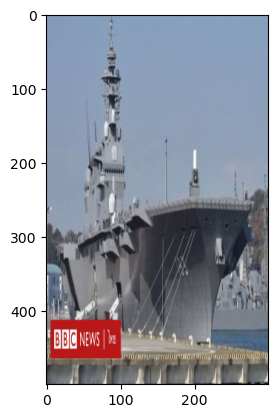

In [29]:
def resize(image, new_height, new_width, mode=None):
    if mode not in ['zero', 'bilinear', 'cubic']:
        raise ValueError(f'Invalid mode {mode}. Supported modes are zero, bilinear, cubic')
    
    if len(image.shape) == 3:
        old_height, old_width, channels = image.shape
    else:
        old_height, old_width = image.shape
        channels = 1
        image = np.expand_dims(image, axis=2)
    
    def P(x):
        return max(x, 0)

    def R(k):
        return (1/6)*(P(k+2)**3 - 4*P(k+1)**3 - 4*P(k-1)**3 + 6*P(k)**3)
        
    resized_image = np.zeros((new_height, new_width, channels), dtype=image.dtype)
    
    scale_x = old_width / new_width
    scale_y = old_height / new_height
    
    for row in range(new_height):
        for col in range(new_width):
            x = col * scale_x
            y = row * scale_y
            
            x0, y0 = floor(x), floor(y)
            x1, y1 = ceil(x), ceil(y)
            
            dx = x - x0
            dy = y - y0
            
            for channel in range(channels):
                def f(x, y):
                    if y >= old_height or x >= old_width:
                        return 0
                    return float(image[y, x, channel])
    
                if mode == 'zero' or mode is None:
                    pixel = image[y0, x0, channel]
                    
                if mode == 'bilinear':
                    pixel = f(x0, y0) + (f(x1, y0) - f(x0, y0))*dx\
                                    + (f(x0, y1) - f(x0, y0))*dy\
                                    + (f(x1, y1) + f(x0, y0) - f(x0, y1) - f(x1, y0))*dx*dy

                if mode == 'cubic':
                    pixel = 0
                    for m in range(-1, 3):
                        for n in range(-1, 3):
                            pixel += f(x0 + m, y0 + n)*R(m - dx)*R(dy - n)
                            
                                  
                resized_image[row, col, channel] = pixel
    if channels == 1:
        resized_image = np.squeeze(resized_image, axis = 2)
    
    return resized_image

img = plt.imread('/home/crueang/Chaks/image_processing-2024/data/Ship/Train/battleship/b1.jpg')
img = resize(img, 500, 300, mode='cubic')
plt.imshow(img)

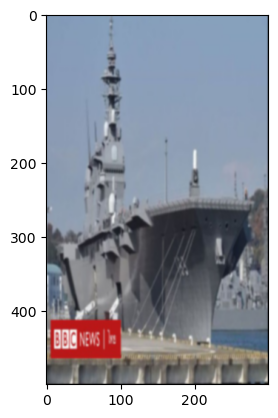

In [30]:
import torch
import torch.nn.functional as F
def gaussian_blur(image, kernel_size, sd):
    # only accept odd kernel_size
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be odd.")
    
    kernel = np.zeros((kernel_size, kernel_size), np.float32)
    half_ks = kernel_size // 2
    for y in range(-half_ks, half_ks + 1):
        for x in range(-half_ks, half_ks + 1):
            normal = 1 / (2 * np.pi * sd**2)
            exp_term = np.exp(-(x**2 + y**2) / (2 * sd**2))
            kernel[y + half_ks, x + half_ks] = normal * exp_term

    kernel /= np.sum(kernel)
    kernel = torch.tensor(kernel)
    kernel = kernel.view(1, 1, kernel_size, kernel_size)
    
    image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
    blurred_image = torch.zeros_like(image_tensor)
    
    for c in range(blurred_image.shape[1]):
        blurred_image[:, c, :, :] = F.conv2d(image_tensor[:, c, :, :], kernel, padding=half_ks)
        
    return blurred_image.squeeze().permute(1, 2, 0).numpy().astype(np.uint8)

img = gaussian_blur(img, 5, 1)
plt.imshow(img)

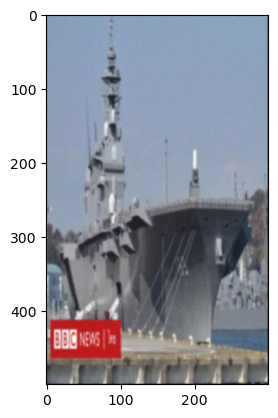

In [31]:
def gaussian_noise(image, mean, sd, p):
    mask = np.random.rand(*image.shape) < p
    noise = np.random.normal(mean, sd, image.shape)
    noisy_image = image + noise
    noisy_image = np.where(mask, noisy_image, image)
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

img = gaussian_noise(img, np.random.uniform(-20, 20), 1, 0.5)
plt.imshow(img)

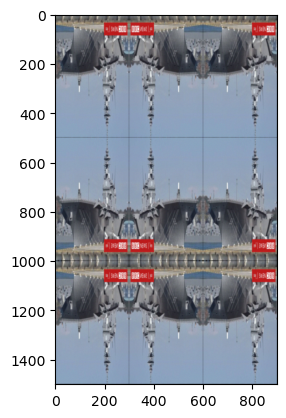

In [32]:
def pad(image, pad_height, pad_width):
    h, w, c = image.shape
    ph = h + 2*pad_height
    pw = w + 2*pad_width
    
    padded_image = np.zeros((ph, pw, c), dtype=image.dtype)
    
    padded_image[pad_height:pad_height + h, pad_width:pad_width + w] = image
    
    padded_image[:pad_height, pad_width:-pad_width] = image[pad_height::-1, :]
    padded_image[-pad_height:, pad_width:-pad_width] = image[-1:-pad_height-1:-1, :]
    
    padded_image[pad_height:-pad_height, :pad_width] = image[:, pad_width::-1]
    padded_image[pad_height:-pad_height, -pad_width:] = image[:, -1:-pad_width-1:-1]
    
    padded_image[:pad_height, :pad_width] = image[pad_height::-1, pad_width::-1]
    padded_image[:pad_height, -pad_width:] = image[pad_height::-1, -1:-pad_width-1:-1]
    padded_image[-pad_height:, :pad_width] = image[-1:-pad_height-1:-1, pad_width::-1]
    padded_image[-pad_height:, -pad_width:] = image[-1:-pad_height-1:-1, -1:-pad_width-1:-1]
    
    return padded_image

img = pad(img, 500, 300)
plt.imshow(img)

In [33]:
def translateMatrix(image, value=(0, 0)):
    original_height, original_width, channels = image.shape

    translate_image = np.zeros((original_height, original_width, channels), dtype=image.dtype)

    for i in range(original_height):
        for j in range(original_width):
            
            orig_y = i - value[1]
            orig_x = j - value[0]

            if 0 <= round(orig_y) < original_height and 0 <= round(orig_x) < original_width:
                translate_image[i, j] = image[round(orig_y), round(orig_x)]
    return translate_image

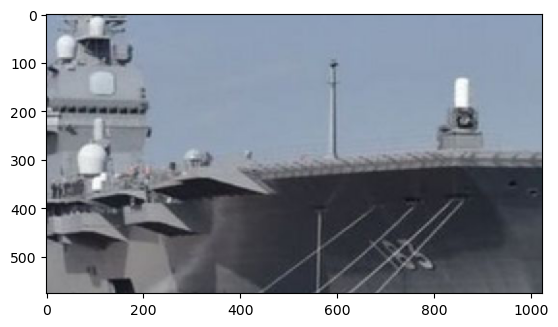

In [34]:
def scaleMatrix(image, scale_factors=1):
    original_height, original_width, channels = image.shape

    scaled_image = np.zeros((original_height, original_width, channels), dtype=image.dtype)
    
    center_x = original_width/2
    center_y = original_height/2
    
    scale_factors = 1/scale_factors
    
    scale_matrix = np.array([
        [scale_factors, 0, -center_x*(scale_factors - 1)],
        [0, scale_factors, -center_y*(scale_factors - 1)],
        [0, 0, 1]
    ])

    for i in range(original_height):
        for j in range(original_width):

            orig_x, orig_y, _ = np.dot(scale_matrix, [j, i, 1])

            if 0 <= round(orig_y) < original_height and 0 <= round(orig_x) < original_width:
                scaled_image[i, j] = image[round(orig_y), round(orig_x)]

    return scaled_image

img = plt.imread('/home/crueang/Chaks/image_processing-2024/data/Ship/Train/battleship/b1.jpg')
img = scaleMatrix(img, 2)
plt.imshow(img)

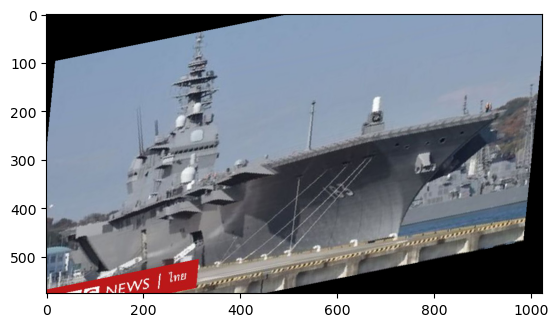

In [35]:
def shearMatrix(image, shear_factors=(1, 1)):
    original_height, original_width, channels = image.shape

    sheared_image = np.zeros((original_height, original_width, channels), dtype=image.dtype)
    
    shx, shy = shear_factors[0], shear_factors[1]
    
    det = abs(1 - shx*shy)
    if det == 0:
        raise ValueError('determinant is zero')
    
    shear_matrix = (1/det) * np.array([
        [1, shx, -shx*original_height/2],
        [shy, 1, -shy*original_width/2],
        [0, 0, 1]
    ])

    for i in range(original_height):
        for j in range(original_width):

            x, y, _ = np.dot(shear_matrix, [j, i, 1])

            if 0 <= round(y) < original_height and 0 <= round(x) < original_width:
                sheared_image[i, j] = image[round(y), round(x)]

    return sheared_image

img = plt.imread('/home/crueang/Chaks/image_processing-2024/data/Ship/Train/battleship/b1.jpg')
img = shearMatrix(img, (0.1, 0.2))
plt.imshow(img)

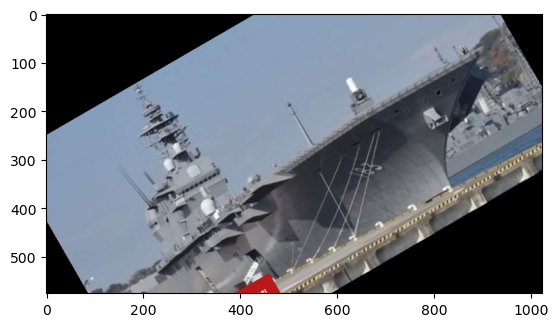

In [36]:
def rotationMatrix(image, degree=0):
    original_height, original_width, channels = image.shape
    theta = math.radians(degree)

    rotated_image = np.zeros((original_height, original_width, channels), dtype=image.dtype)
    
    center_x = original_width / 2
    center_y = original_height / 2
    
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta), center_x * (1 - np.cos(theta)) + center_y * np.sin(theta)],
        [np.sin(theta), np.cos(theta), center_y * (1 - np.cos(theta)) - center_x * np.sin(theta)],
        [0, 0, 1]
    ])

    for i in range(original_height):
        for j in range(original_width):
            x, y, _ = np.dot(rotation_matrix, [j, i, 1])

            if 0 <= round(y) < original_height and 0 <= round(x) < original_width:
                rotated_image[i, j] = image[round(y), round(x)]

    return rotated_image

img = plt.imread('/home/crueang/Chaks/image_processing-2024/data/Ship/Train/battleship/b1.jpg')
img = rotationMatrix(img, 30)
plt.imshow(img)

In [37]:
def center_crop(image, crop_h, crop_w):
    h, w = image.shape[:2]
    h, w = h//2, w//2
    crop_h = crop_h // 2
    crop_w = crop_w // 2
    
    return image[h-crop_h:h+crop_h, w-crop_w:w+crop_w,:]

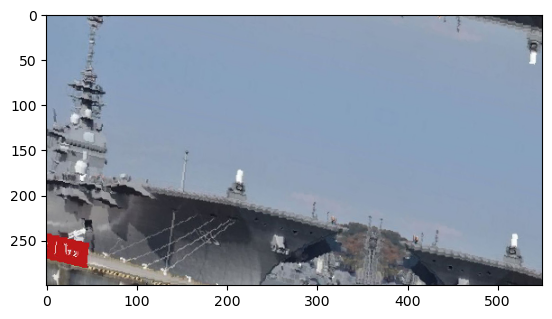

In [38]:

def random_affine(image, degrees=0, translate=(0, 0), scale=(1, 1), shear=(0, 0)):
    angle = random.uniform(-degrees, degrees)
    
    max_dx = int(translate[0] * image.shape[1])
    max_dy = int(translate[1] * image.shape[0])
    translations = (random.uniform(-max_dx, max_dx), random.uniform(-max_dy, max_dy))


    scale_factor = random.uniform(scale[0], scale[1])


    shear_x = random.uniform(-shear[0], shear[0])
    shear_y = random.uniform(-shear[1], shear[1])

    image = translateMatrix(image, translations)
    image = scaleMatrix(image, scale_factor)
    image = shearMatrix(image, (shear_x, shear_y))
    image = rotationMatrix(image, angle)
    return image


img_height, img_width = 300, 550

img = plt.imread('/home/crueang/Chaks/image_processing-2024/data/Ship/Train/battleship/b1.jpg')
img = resize(img, img_height, img_width, 'zero')
img = pad(img, img_height, img_width)
img = random_affine(img, degrees=10, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=(0.2, 0.2))
img = center_crop(img, img_height, img_width)
plt.imshow(img)

torch.Size([3, 224, 224])


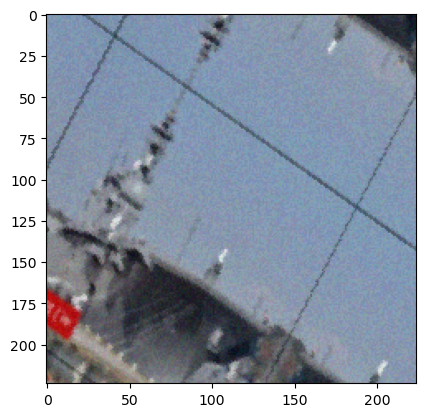

In [55]:
image = plt.imread('/home/crueang/Chaks/image_processing-2024/data/Ship/Train/battleship/b1.jpg')
image = np.array(image)
image = resize(image,224, 224, mode='cubic')
kernel_size = random.randrange(3, 12, 2)
blur_image = gaussian_blur(image,kernel_size,1)
image = gaussian_noise(blur_image, np.random.uniform(-20, 20), 1, 0.5)
image = pad(image,224,224)
image = random_affine(image,degrees=45, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=(0.25,0))
image = center_crop(image,224,224)
# image = transforms.ToTensor()(image)
image = Image.fromarray(np.uint8(image))
plt.imshow(image.permute(1, 2, 0))

torch.Size([3, 224, 224])


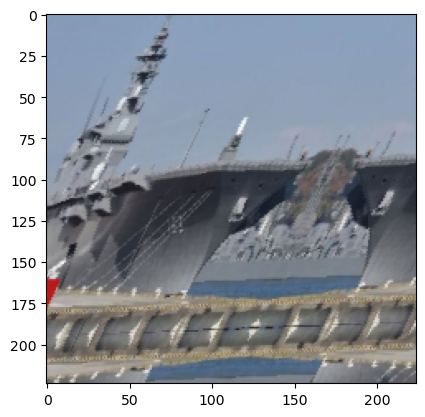

In [50]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset
from torch.nn import functional as F
import random
import cv2
import numpy as np
from skimage.util import random_noise
import matplotlib.pyplot as plt
import os
import math
from PIL import Image
image = plt.imread('/home/crueang/Chaks/image_processing-2024/data/Ship/Train/battleship/b1.jpg')
image = Image.fromarray(np.uint8(image))
image = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Pad(padding=224, padding_mode='reflect'),
        transforms.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=45),
        transforms.CenterCrop((224, 224)),
        transforms.ToTensor(),
    ])(image)
print(image.shape)
plt.imshow(image.permute(1, 2, 0))